In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Exploratory Data Analysis 

## Datos a emplear: ECG Heartbeat Categorization Dataset

Este conjunto de datos se compone de dos colecciones de señales de latidos cardíacos derivadas de dos conjuntos de datos famosos en la clasificación de latidos cardíacos, el MIT-BIH Arrhythmia Dataset y The PTB Diagnostic ECG Database. El número de muestras en ambas colecciones es lo suficientemente grande como para entrenar incluso una red neuronal profunda.
Las señales corresponden a formas de electrocardiogramas (ECG) de latidos cardíacos para el caso normal y los casos afectados por diferentes arritmias e infarto de miocardio. Estas señales se preprocesan y segmentan, correspondiendo cada segmento a un latido cardíaco.

El dataset está compuesto por 187 varaibles que representan un latido de un electrocardiograma entre [R-R]  y una columna de label que representa el tipo de latido, como se muestra en la siguente figura:

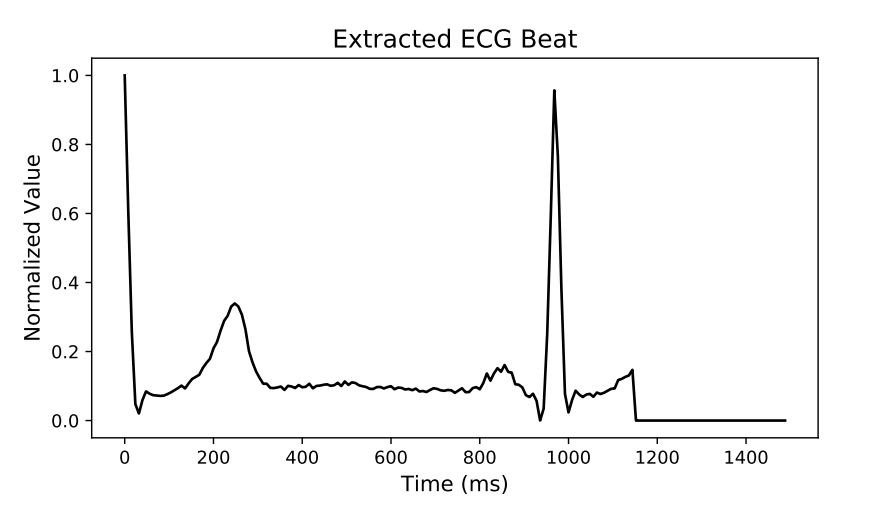


Las labels son: ['N': 0, 'S': 1, 'V': 2, 'F': 3, 'Q': 4]

N: Latidos normales y bloqueos

S: Latidos supraventriculares anormales

V: Latidos ventriculares anormales

F: Latidos fusionados

Q: Latidos artificiales o no clasificados







Nota: Para entender los datos podemos ver el siguiente  [paper](https://arxiv.org/pdf/1805.00794)

In [8]:
path = "../../proyecto/data/mitbih_train.csv"
df = pd.read_csv(path, header=None)
df.rename(columns={187:"label"}, inplace=True) #renombrar la columna de label

print("Dimensiones del dataset:", df.shape)

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

Dimensiones del dataset: (87554, 188)


## Exploración y descripción de los datos

### Resumen estadistico

El dataset consta de 188 columnunas y en la tabla continua podemos ver las metricas estadisticas mas representativas para cada una de esas variables


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87554 entries, 0 to 87553
Columns: 188 entries, 0 to label
dtypes: float64(188)
memory usage: 125.6 MB


In [5]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,label
count,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,...,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000
mean,0.890360,0.758160,0.423972,0.219104,0.201127,0.210399,0.205808,0.201773,0.198691,0.196757,...,0.005025,0.004628,0.004291,0.003945,0.003681,0.003471,0.003221,0.002945,0.002807,0.473376
std,0.240909,0.221813,0.227305,0.206878,0.177058,0.171909,0.178481,0.177240,0.171778,0.168357,...,0.044154,0.042089,0.040525,0.038651,0.037193,0.036255,0.034789,0.032865,0.031924,1.143184
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.921922,0.682486,0.250969,0.048458,0.082329,0.088416,0.073333,0.066116,0.065000,0.068639,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.991342,0.826013,0.429472,0.166000,0.147878,0.158798,0.145324,0.144424,0.150000,0.148734,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.910506,0.578767,0.341727,0.258993,0.287628,0.298237,0.295391,0.290832,0.283636,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000


### Análisis de los labels

In [7]:
df["label"].value_counts(normalize=True)

,proportion
label,
0.0,0.827729
4.0,0.073452
2.0,0.066108
1.0,0.025390
3.0,0.007321


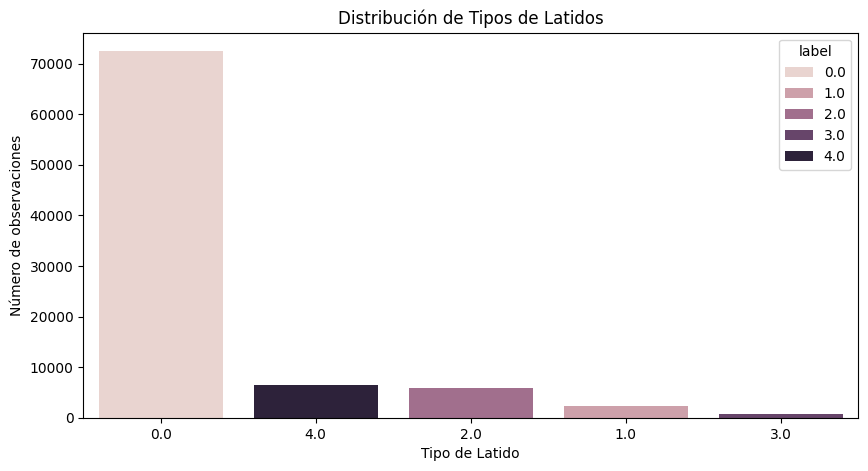

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(x=df["label"], order=df["label"].value_counts().index, hue=df["label"])
plt.xlabel("Tipo de Latido")
plt.ylabel("Número de observaciones")
plt.title("Distribución de Tipos de Latidos")
plt.show();

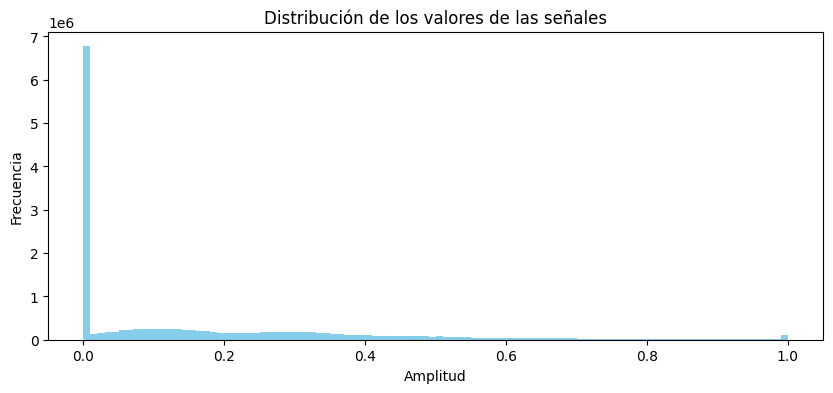

In [9]:
# Histograma de todos los valores de señales (con flatten)
plt.figure(figsize=(10, 4))
plt.hist(X.values.flatten(), bins=100, color='skyblue')
plt.title("Distribución de los valores de las señales")
plt.xlabel("Amplitud")
plt.ylabel("Frecuencia")
plt.show()

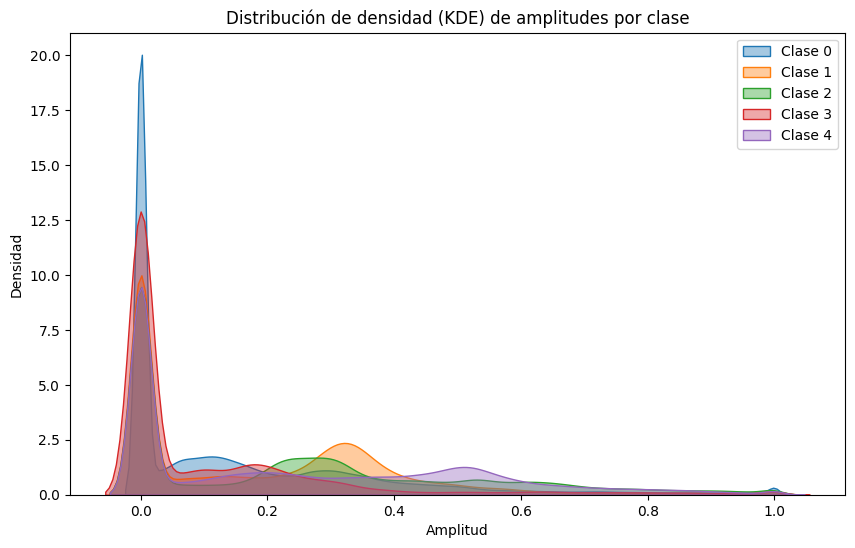

In [10]:
clases = sorted(y.unique())
plt.figure(figsize=(10, 6))
for clase in clases:
    sns.kdeplot(X[y == clase].values.flatten(), label=f'Clase {int(clase)}', fill=True, alpha=0.4)

plt.title("Distribución de densidad (KDE) de amplitudes por clase")
plt.xlabel("Amplitud")
plt.ylabel("Densidad")
plt.legend()
plt.show()

Evidentemente se puede asegurar que Hay un fuerte desbalance de clases, la clase 0.0 domina completamente el dataset y la clase 3.0 tiene menos del 1% de las muestras lo cual nos obligara a usar tecnicas de balanceo para un correcto entrenamiento del modelo.


KDE significa Kernel Density Estimation (Estimación de Densidad por Núcleo). Es una técnica no paramétrica que estima la función de densidad de probabilidad de una variable aleatoria, a partir de una muestra. 
Me permite sugerir aplicar técnicas de reducción de dimensionalidad (PCA, t-SNE) para ver si las clases son separables en base a amplitudes y usar esta información para diseñar estrategias de preprocesamiento o extracción de características.

### Visualización de ejemplos por clase

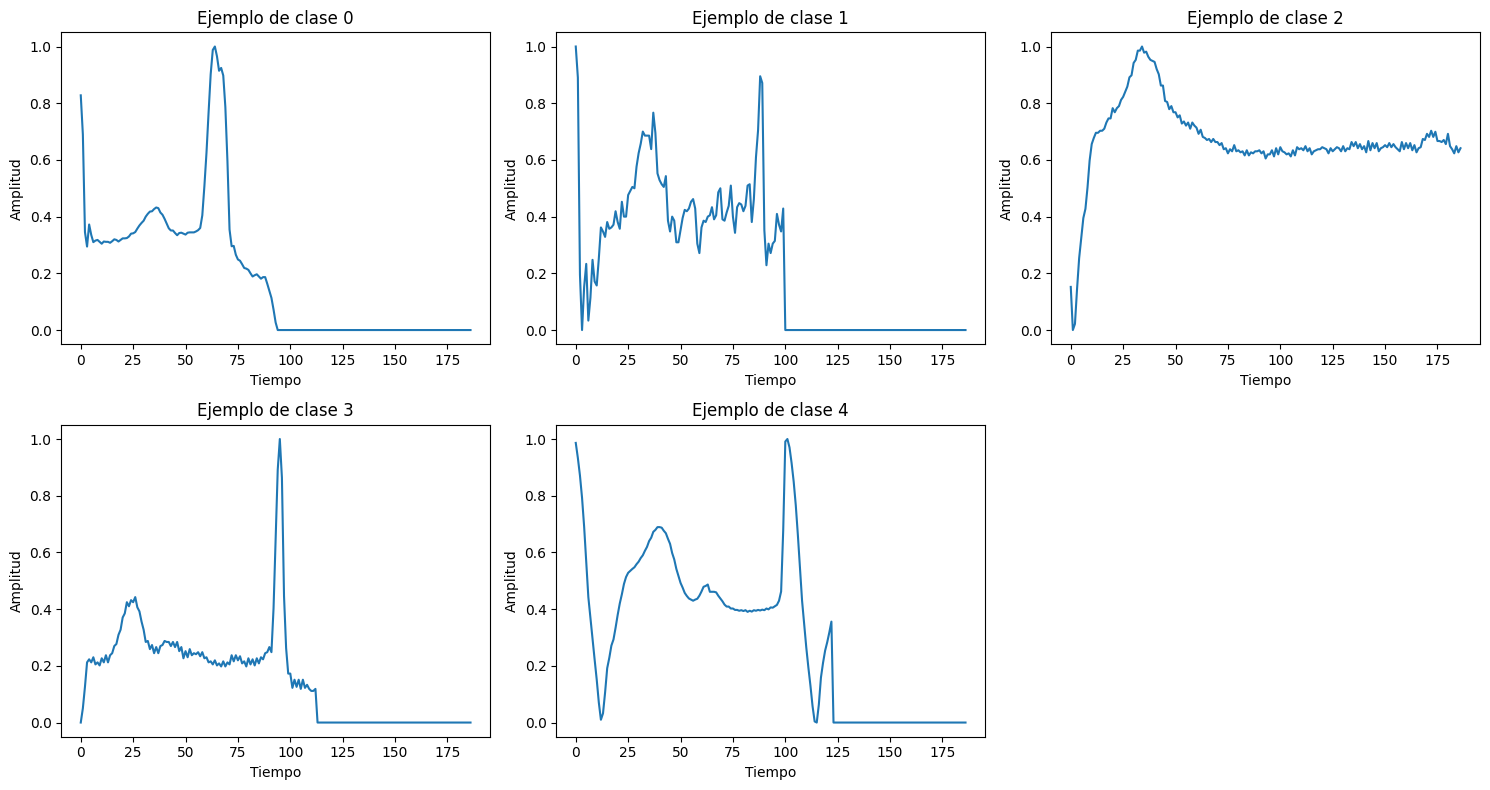

In [11]:
clases = y.unique()

plt.figure(figsize=(15, 8))
for i, clase in enumerate(sorted(clases)):
    idx = y[y == clase].sample(1).index[0]  
    señal = X.iloc[idx]
    plt.subplot(2, 3, i + 1)
    plt.plot(señal.values)
    plt.title(f"Ejemplo de clase {int(clase)}")
    plt.xlabel("Tiempo")
    plt.ylabel("Amplitud")

plt.tight_layout()
plt.show()

### Estadísticas descriptivas

In [12]:
print("\nEstadísticas de las señales:")
print(X.describe().T[['mean', 'std', 'min', 'max']])


Estadísticas de las señales:
         mean       std  min  max
0    0.890360  0.240909  0.0  1.0
1    0.758160  0.221813  0.0  1.0
2    0.423972  0.227305  0.0  1.0
3    0.219104  0.206878  0.0  1.0
4    0.201127  0.177058  0.0  1.0
..        ...       ...  ...  ...
182  0.003681  0.037193  0.0  1.0
183  0.003471  0.036255  0.0  1.0
184  0.003221  0.034789  0.0  1.0
185  0.002945  0.032865  0.0  1.0
186  0.002807  0.031924  0.0  1.0

[187 rows x 4 columns]


Obtenemos el resumen estadístico por variable.
Los valores se encuentra contenidos entre 0 y 1. 
De los datos podemos inferir que la actividad más importante ocurre al principio o en el medio de la señal. Al final de muchas señales parece ser plano o sin mucha información, esto también lo puedes confirmar con la energía o KDE, revisado anteriormente.

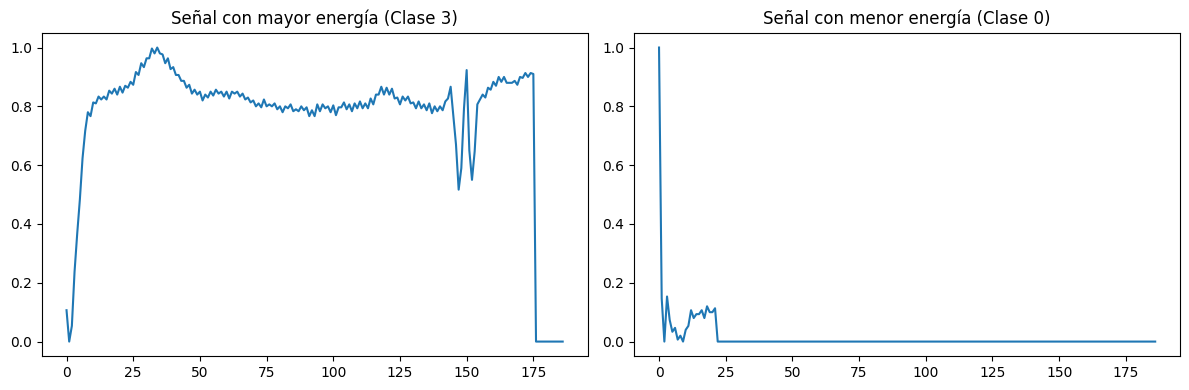

In [13]:
energia = X.apply(lambda x: np.sum(x**2), axis=1)
idx_max = energia.idxmax()
idx_min = energia.idxmin()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(X.iloc[idx_max])
plt.title(f"Señal con mayor energía (Clase {int(y[idx_max])})")

plt.subplot(1, 2, 2)
plt.plot(X.iloc[idx_min])
plt.title(f"Señal con menor energía (Clase {int(y[idx_min])})")
plt.tight_layout()
plt.show()

### Señales Extremas Energía máxima y mínima

Evaluación de diversidad en las señales
Las señales más energéticas pueden estar asociadas a latidos más violentos o anormales.
Las señales con baja energía pueden representar latidos débiles o inusuales.
Puede ayudarte a entender el rango de comportamiento cardíaco en el dataset.

### Distribuciones y correlaciones lineales

In [ ]:
correlations = df.corr()

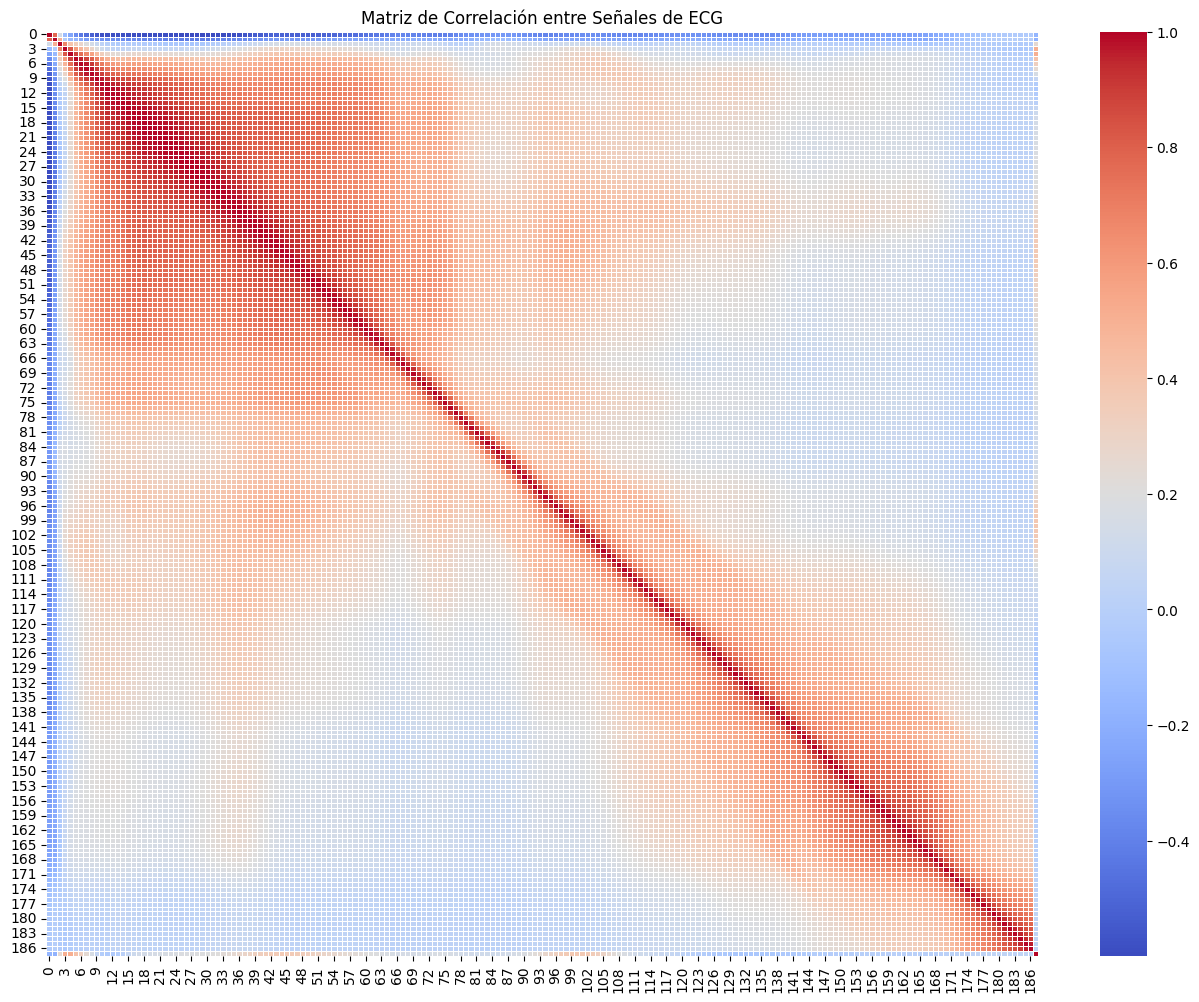

''

In [ ]:
plt.figure(figsize=(16, 12))
sns.heatmap(correlations, cmap="coolwarm", linewidths=0.5)
plt.title("Matriz de Correlación entre Señales de ECG")
plt.show();

In [ ]:
correlations["label"].sort_values(ascending=False).head(15)

,label
label,1.000000
3,0.508486
4,0.508453
5,0.408177
100,0.378922
99,0.376441
101,0.373843
98,0.366129
102,0.366069
44,0.364318


Esto es una forma de feature selection básica, para identificar qué variables tienen mayor relación con la clase.
Se puede infereir viendo el mapa de calor que hay segmentos específicos de la señal ECG donde ocurren características distintivas de cada clase.
Ahora procederemos con un nuevo Dataset solo con estas columnas top.

In [14]:
top_features = [3, 4, 5, 100, 99, 101, 102, 98, 44, 45, 43, 46, 42, 103, 'label']
df_top = df[top_features].copy()
df_top.columns = [str(col) for col in df_top.columns]

corr_matrix = df_top.corr()

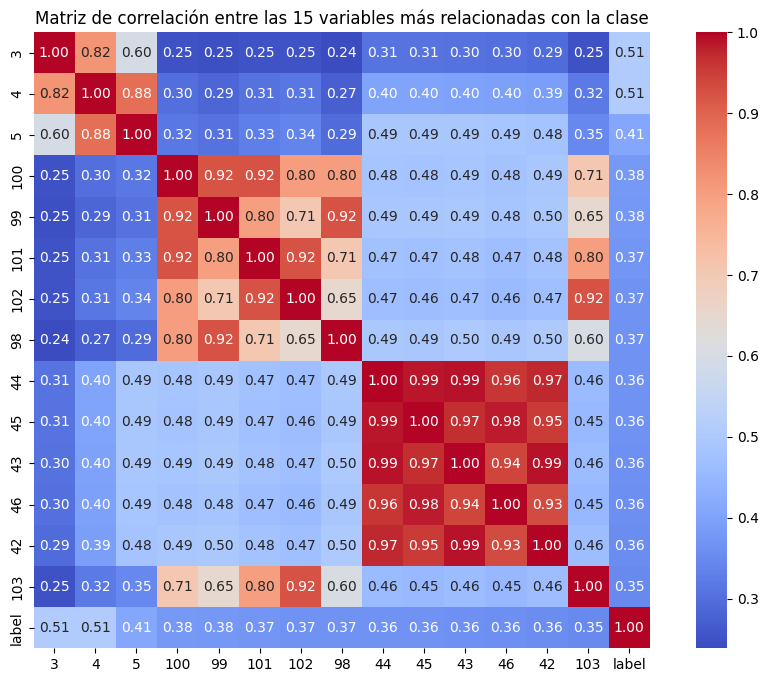

In [15]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Matriz de correlación entre las 15 variables más relacionadas con la clase")
plt.show()

En analiis de correlacion lineal solo entre las variables mas correlacionadas linealmente nos permite inferir lo siguiente:
Variables 44, 45, 43, 46, 42 tienen correlaciones muy altas entre sí. Esta informacion nos daria indicio de poder hacer una reducion de la dimensionalidad manteniendo solo una o dos de ellas sin perder mucha información.

Column:  3
Skew: 1.08
Kurtosis:  0.71


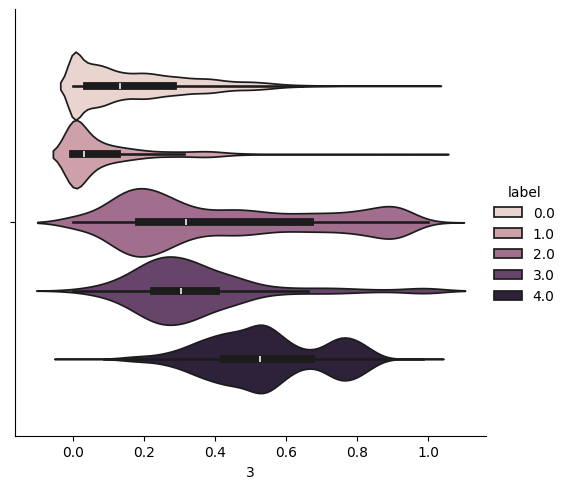

Column:  4
Skew: 1.58
Kurtosis:  2.5


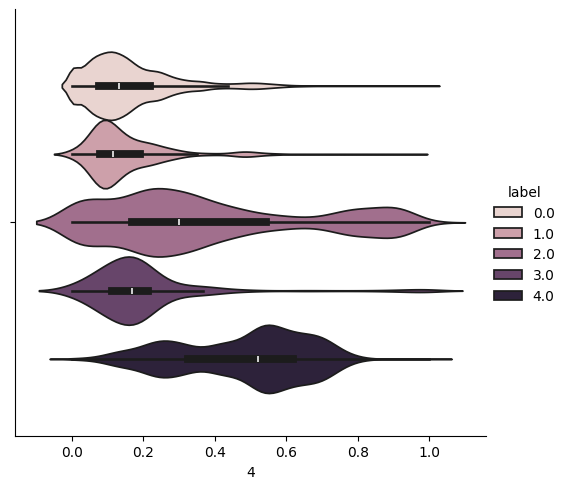

Column:  5
Skew: 1.39
Kurtosis:  1.85


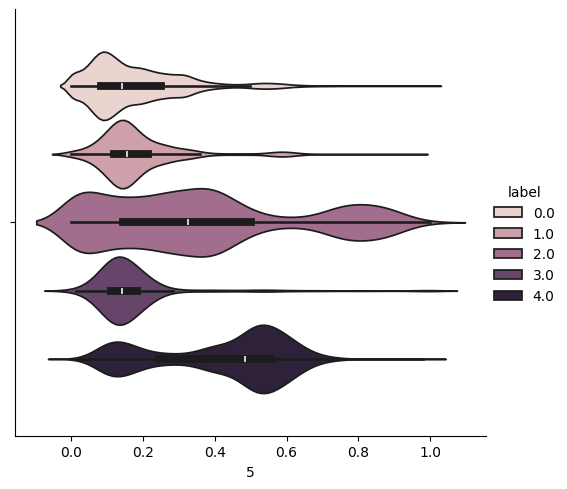

Column:  100
Skew: 1.42
Kurtosis:  1.35


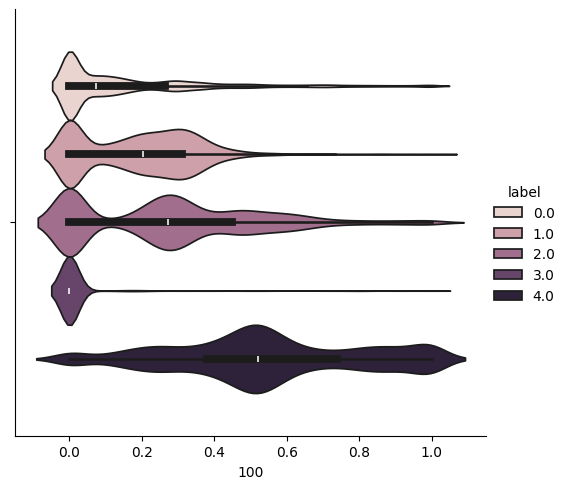

Column:  99
Skew: 1.41
Kurtosis:  1.36


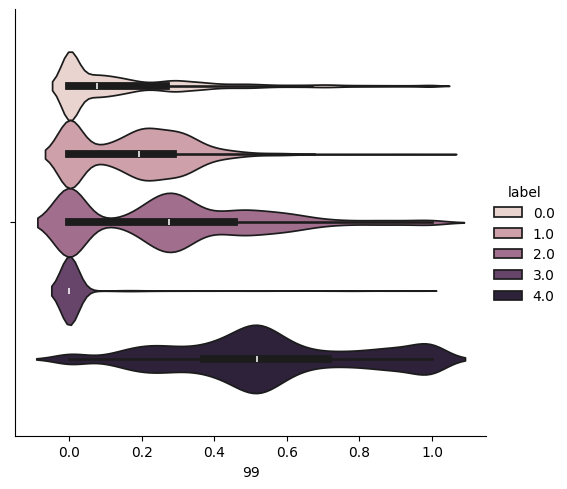

Column:  101
Skew: 1.44
Kurtosis:  1.37


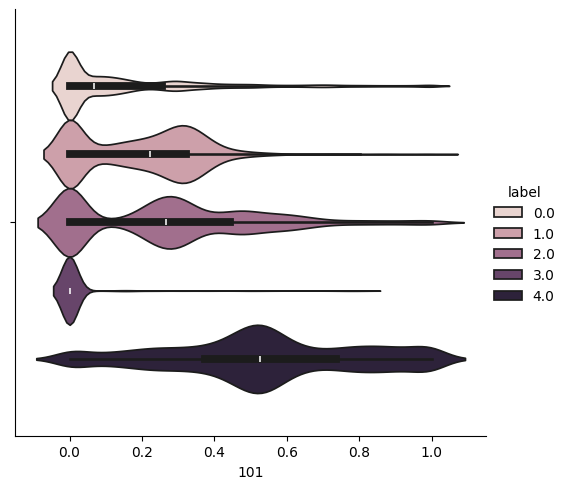

Column:  98
Skew: 1.41
Kurtosis:  1.42


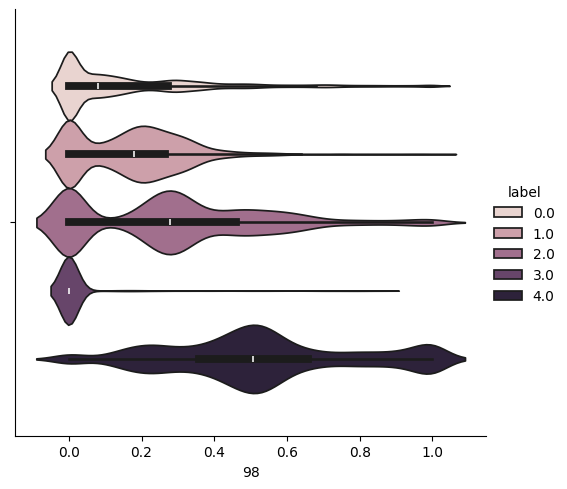

Column:  102
Skew: 1.46
Kurtosis:  1.41


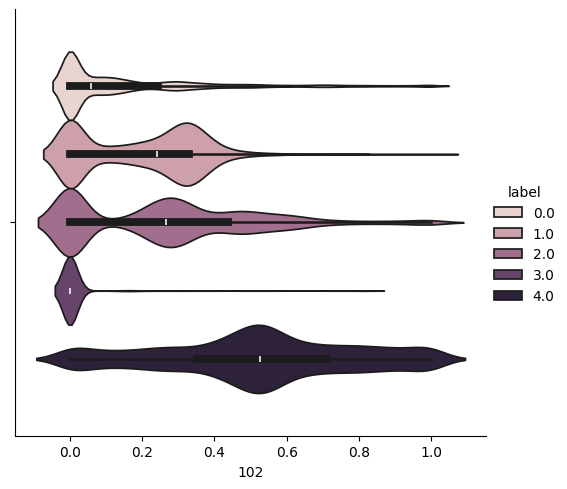

Column:  44
Skew: 1.11
Kurtosis:  0.92


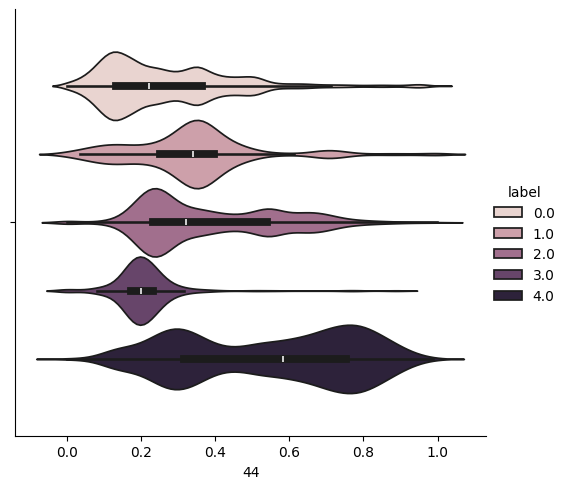

Column:  45
Skew: 1.11
Kurtosis:  0.96


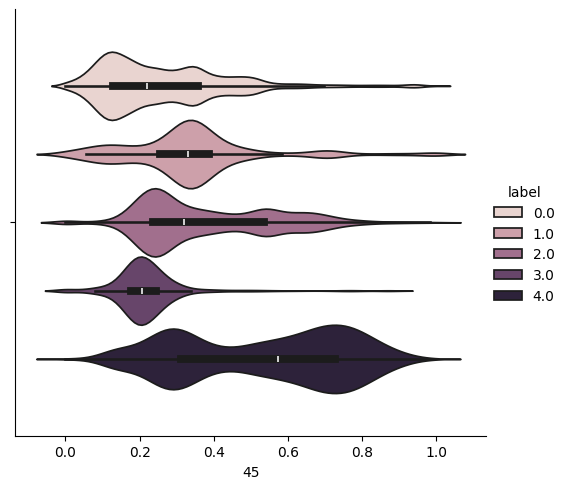

Column:  43
Skew: 1.11
Kurtosis:  0.9


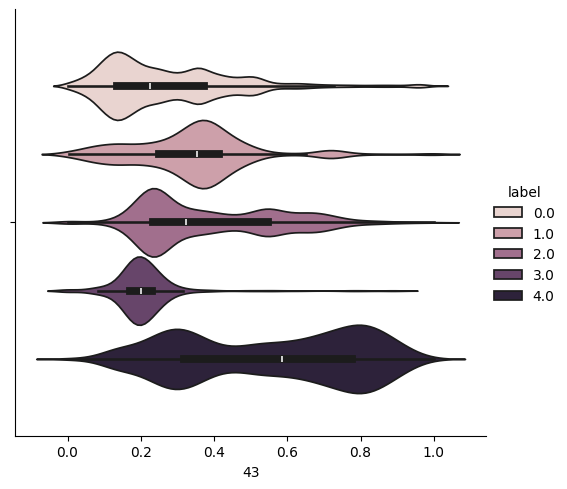

Column:  46
Skew: 1.1
Kurtosis:  1.0


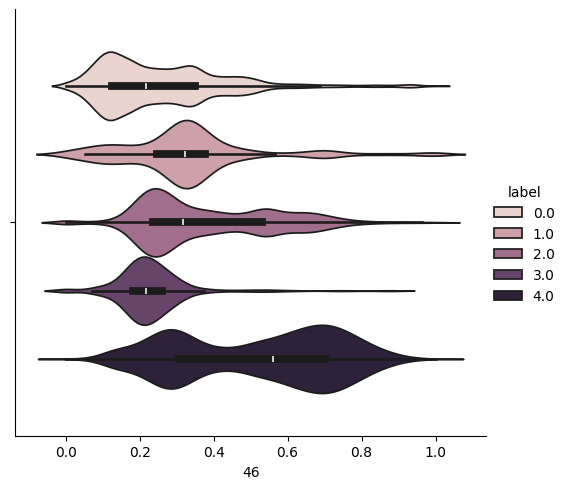

Column:  42
Skew: 1.11
Kurtosis:  0.89


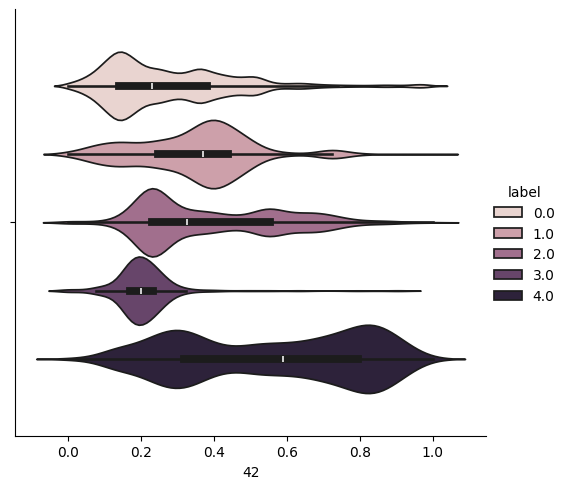

Column:  47
Skew: 1.09
Kurtosis:  1.01


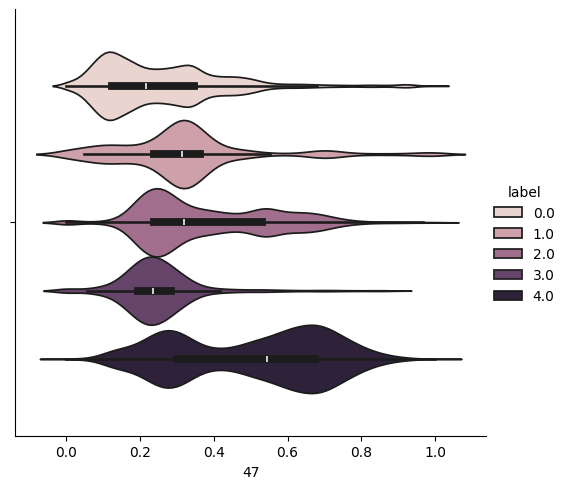

In [ ]:
columns = correlations["label"].sort_values(ascending=False).head(15).index[1:].values

for col in columns:
    print('Column: ', col)
    print('Skew:', round(df[col].skew(), 2))
    print('Kurtosis: ', round(df[col].kurtosis(), 2))
    sns.catplot(data=df, x=col, hue="label", kind="violin")
    plt.show()

Anteriormente vemos graficamente lo que se visualizo previamente. 
Despues de este analisis de correlacion podriamos proceder con:
* Reducir columnas redundantes- Podria ser con un PCA
* Entrenar un modelo simple solo con estas columnas y comparar con el modelo completo.
* Visualizar la separación de clases en un espacio 2D con t-SNE o PCA.

### Test de Kruskal-Wallis

El test de Kruskal-Wallis es una prueba estadística no paramétrica que se utiliza para determinar si hay diferencias significativas entre las medianas de dos o más grupos independientes.
Es una alternativa al ANOVA cuando no se puede asumir que los datos siguen una distribución normal.

In [ ]:
import scipy.stats as stats

classes = df['label'].unique()
col = 3

stat, p_value = stats.kruskal(*(df[df['label'] == c][3] for c in classes))
test_used = "Kruskal-Wallis"

print(f"Test utilizado: {test_used}")
print(f"Estadístico: {stat:.4f}, p-valor: {p_value:.4f}")

if p_value < 0.05:
    print("Diferencia estadísticamente significativa entre las clases.")
else:
    print("No hay evidencia suficiente para afirmar diferencia estadística entre clases.")

Test utilizado: Kruskal-Wallis
Estadístico: 17933.5488, p-valor: 0.0000
Diferencia estadísticamente significativa entre las clases.


En este caso, probamos si el valor de la clase 3 de la señal es estadísticamente diferente entre las distintas clases 
El estadístico de Kruskal-Wallis es muy alto, lo que sugiere una diferencia fuerte.
Como el p-valor es menor a 0.05, se rechaza la hipótesis nula.
Esto significa que existe evidencia estadísticamente significativa de que la variable en la columna 3 toma valores diferentes en al menos una clase.

### PCA

PCA para reducir la dimensionalidad de las señales de ECG, que originalmente tienen 187 variables por señal. Procederemos a proyectar los datos en 3 dimensiones (3 componentes principales)
* Reducción de dimensionalidad: pasas de 187 dimensiones a 3 con pérdida controlada de información.
* Visualizaremos los datos en 3D (scatter 3D por clase).
* Sirve para preprocesamiento de modelos más eficientes y rápidos.

In [16]:
pca3d = PCA(n_components=3)
X_pca3d = pca3d.fit_transform(X)

print(f"Varianza explicada por cada componente: {pca3d.explained_variance_ratio_}")
print(f"Varianza total explicada: {sum(pca3d.explained_variance_ratio_)}")

Varianza explicada por cada componente: [0.43509787 0.10661903 0.0714575 ]
Varianza total explicada: 0.6131743998093344


In [ ]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'iframe_connected'

df_pca = pd.DataFrame(X_pca3d, columns=["PC1", "PC2", "PC3"])
df_pca["label"] = y

fig = px.scatter_3d(df_pca, x="PC1", y="PC2", z="PC3", color=df_pca["label"].astype(str),
                     title="PCA 3D",
                     labels={"color": "Tipo de Latido"}, opacity=0.7)

fig.show()

## Conclusiones